In [118]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [119]:
us = pd.read_csv('Cleaned US Electric Vehicle.csv')

In [120]:
us

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,Vehicle Location,Electric Utility,2020 Census Tract
0,3C3CFFGE4E,Yakima,Yakima,WA,98902.0,2014,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87,0,14.0,POINT (-120.524012 46.5973939),PACIFICORP,5.307700e+10
1,5YJXCBE40H,Thurston,Olympia,WA,98513.0,2017,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200,0,2.0,POINT (-122.817545 46.98876),PUGET SOUND ENERGY INC,5.306701e+10
2,3MW39FS03P,King,Renton,WA,98058.0,2023,BMW,330E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,20,0,11.0,POINT (-122.1298876 47.4451257),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
3,7PDSGABA8P,Snohomish,Bothell,WA,98012.0,2023,RIVIAN,R1S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,POINT (-122.1873 47.820245),PUGET SOUND ENERGY INC,5.306105e+10
4,5YJ3E1EB8L,King,Kent,WA,98031.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322,0,33.0,POINT (-122.2012521 47.3931814),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10305,WP0CE2A78N,King,Vashon,WA,98070.0,2022,PORSCHE,PANAMERA,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,18,0,34.0,POINT (-122.46049 47.44873),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
10306,YV4BR0CK5K,Pierce,Puyallup,WA,98372.0,2019,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,17,0,31.0,POINT (-122.28718 47.190465),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.305394e+10
10307,WP0CD2Y10N,Pierce,Gig Harbor,WA,98335.0,2022,PORSCHE,TAYCAN,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,26.0,POINT (-122.5835454 47.3234488),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305307e+10
10308,YV4ER3XM7R,King,Seattle,WA,98122.0,2024,VOLVO,XC40,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,43.0,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10


In [121]:
us.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='object')

In [122]:
print(us.columns.tolist())


['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range', 'Base MSRP', 'Legislative District', 'Vehicle Location', 'Electric Utility', '2020 Census Tract']


In [123]:
us.drop(['VIN (1-10)', 'Postal Code','Vehicle Location','2020 Census Tract','Electric Utility'], axis = 1 , inplace = True)

In [124]:
us.columns

Index(['County', 'City', 'State', 'Model Year', 'Make', 'Model',
       'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District'],
      dtype='object')

In [125]:
us['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()

Clean Alternative Fuel Vehicle (CAFV) Eligibility
Clean Alternative Fuel Vehicle Eligible                         4112
Eligibility unknown as battery range has not been researched    3604
Not eligible due to low battery range                           2594
Name: count, dtype: int64

In [126]:
def encode_cafv(eligibility):
    if 'Clean Alternative Fuel Vehicle Eligible' in eligibility:
        return 2
    elif 'Not eligible' in eligibility:
        return 0
    else:
        return 1  # For "Eligibility unknown"
        
us['CAFV_Encoded'] = us['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].apply(encode_cafv)



In [127]:
us.drop(columns="Clean Alternative Fuel Vehicle (CAFV) Eligibility",inplace=True)

In [128]:
us

,County,City,State,Model Year,Make,Model,Electric Vehicle Type,Electric Range,Base MSRP,Legislative District,CAFV_Encoded
0,Yakima,Yakima,WA,2014,FIAT,500,Battery Electric Vehicle (BEV),87,0,14.0,2
1,Thurston,Olympia,WA,2017,TESLA,MODEL X,Battery Electric Vehicle (BEV),200,0,2.0,2
2,King,Renton,WA,2023,BMW,330E,Plug-in Hybrid Electric Vehicle (PHEV),20,0,11.0,0
3,Snohomish,Bothell,WA,2023,RIVIAN,R1S,Battery Electric Vehicle (BEV),0,0,21.0,1
4,King,Kent,WA,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),322,0,33.0,2
...,...,...,...,...,...,...,...,...,...,...,...
10305,King,Vashon,WA,2022,PORSCHE,PANAMERA,Plug-in Hybrid Electric Vehicle (PHEV),18,0,34.0,0
10306,Pierce,Puyallup,WA,2019,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),17,0,31.0,0
10307,Pierce,Gig Harbor,WA,2022,PORSCHE,TAYCAN,Battery Electric Vehicle (BEV),0,0,26.0,1
10308,King,Seattle,WA,2024,VOLVO,XC40,Battery Electric Vehicle (BEV),0,0,43.0,1


In [129]:
categorical_cols = ['County', 'City', 'State', 'Make', 'Model', 
                    'Electric Vehicle Type']
us = pd.get_dummies(us, columns=categorical_cols, drop_first=True)


In [130]:
print(us.columns.tolist())

['Model Year', 'Electric Range', 'Base MSRP', 'Legislative District', 'CAFV_Encoded', 'County_Benton', 'County_Chelan', 'County_Clallam', 'County_Clark', 'County_Cowlitz', 'County_Douglas', 'County_Franklin', 'County_Grant', 'County_Grays Harbor', 'County_Island', 'County_Jefferson', 'County_King', 'County_Kitsap', 'County_Kittitas', 'County_Klickitat', 'County_Lewis', 'County_Mason', 'County_Okanogan', 'County_Pacific', 'County_Pend Oreille', 'County_Pierce', 'County_San Juan', 'County_Skagit', 'County_Skamania', 'County_Snohomish', 'County_Spokane', 'County_Stevens', 'County_Thurston', 'County_Wahkiakum', 'County_Walla Walla', 'County_Whatcom', 'County_Whitman', 'County_Yakima', 'City_Algona', 'City_Amboy', 'City_Anacortes', 'City_Ariel', 'City_Arlington', 'City_Ashford', 'City_Auburn', 'City_Bainbridge Island', 'City_Battle Ground', 'City_Beaux Arts', 'City_Belfair', 'City_Bellevue', 'City_Bellingham', 'City_Benton City', 'City_Black Diamond', 'City_Blaine', 'City_Bonney Lake', 'Cit

In [131]:
print(us.dtypes)

Model Year                                                        int64
Electric Range                                                    int64
Base MSRP                                                         int64
Legislative District                                            float64
CAFV_Encoded                                                      int64
                                                                 ...   
Model_XC40                                                         bool
Model_XC60                                                         bool
Model_XC90                                                         bool
Model_XM                                                           bool
Electric Vehicle Type_Plug-in Hybrid Electric Vehicle (PHEV)       bool
Length: 459, dtype: object


In [132]:
us.columns

Index(['Model Year', 'Electric Range', 'Base MSRP', 'Legislative District',
       'CAFV_Encoded', 'County_Benton', 'County_Chelan', 'County_Clallam',
       'County_Clark', 'County_Cowlitz',
       ...
       'Model_VOLT', 'Model_WHEEGO', 'Model_WRANGLER', 'Model_X3', 'Model_X5',
       'Model_XC40', 'Model_XC60', 'Model_XC90', 'Model_XM',
       'Electric Vehicle Type_Plug-in Hybrid Electric Vehicle (PHEV)'],
      dtype='object', length=459)

## GOal - Estimate the expected electric range based on features like vehicle type, model, and price.



In [134]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [135]:
us.columns

Index(['Model Year', 'Electric Range', 'Base MSRP', 'Legislative District',
       'CAFV_Encoded', 'County_Benton', 'County_Chelan', 'County_Clallam',
       'County_Clark', 'County_Cowlitz',
       ...
       'Model_VOLT', 'Model_WHEEGO', 'Model_WRANGLER', 'Model_X3', 'Model_X5',
       'Model_XC40', 'Model_XC60', 'Model_XC90', 'Model_XM',
       'Electric Vehicle Type_Plug-in Hybrid Electric Vehicle (PHEV)'],
      dtype='object', length=459)

In [157]:
# Replace long strings like 'Eligibility unknown...' with NaN and convert to numeric
us['Electric Range'] = pd.to_numeric(us['Electric Range'], errors='coerce')

# Drop rows where Electric Range is still NaN
# us.drop(columns=['Electric Range'], inplace=True)   #  Correct
us

,Model Year,Electric Range,Base MSRP,Legislative District,CAFV_Encoded,County_Benton,County_Chelan,County_Clallam,County_Clark,County_Cowlitz,...,Model_VOLT,Model_WHEEGO,Model_WRANGLER,Model_X3,Model_X5,Model_XC40,Model_XC60,Model_XC90,Model_XM,Electric Vehicle Type_Plug-in Hybrid Electric Vehicle (PHEV)
0,2014,87,0,14.0,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2017,200,0,2.0,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2023,20,0,11.0,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,2023,0,0,21.0,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2020,322,0,33.0,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10305,2022,18,0,34.0,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10306,2019,17,0,31.0,0,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
10307,2022,0,0,26.0,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10308,2024,0,0,43.0,1,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [93]:
X = us.drop(columns=['Electric Range']).values
y = us['Electric Range'].values

In [ ]:
## Feature Scaling 

In [159]:
from sklearn.preprocessing import StandardScaler 
sc = StandardScaler()

In [161]:
X_train = sc.fit_transform(X_train)

In [163]:
X_test = sc.transform(X_test)

In [165]:
 #Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [167]:
X_test

array([[2019, 0, 43.0, ..., False, False, False],
       [2023, 0, 48.0, ..., False, False, True],
       [2023, 0, 41.0, ..., False, False, False],
       ...,
       [2023, 0, 32.0, ..., False, False, False],
       [2020, 0, 45.0, ..., False, False, True],
       [2024, 0, 1.0, ..., False, False, False]], dtype=object)

In [169]:
# X_train.select_dtypes(include=['object']).head()


,Clean Alternative Fuel Vehicle (CAFV) Eligibility
4981,Eligibility unknown as battery range has not b...
2684,Clean Alternative Fuel Vehicle Eligible
1295,Clean Alternative Fuel Vehicle Eligible
9699,Clean Alternative Fuel Vehicle Eligible
591,Eligibility unknown as battery range has not b...


In [171]:
# X_train = X_train.drop('Clean Alternative Fuel Vehicle (CAFV) Eligibility', axis=1)

In [169]:
# Train model
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

GradientBoostingRegressor()

In [171]:
y_pred = model.predict(X_test)


In [173]:
y_pred

array([ 1.62298970e+02,  3.84134149e+01,  2.22640558e+00, ...,
        2.38732861e-01,  2.17789084e+01, -1.59106342e-01])

In [175]:
print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


R² Score: 0.9859347236095966
MSE: 82.32190990578604


In [ ]:
## check for overfitting 

In [179]:
print("Train R²:", model.score(X_train, y_train))
print("Test R²:", model.score(X_test, y_test))

Train R²: 0.9873240616382944
Test R²: 0.9859347236095966


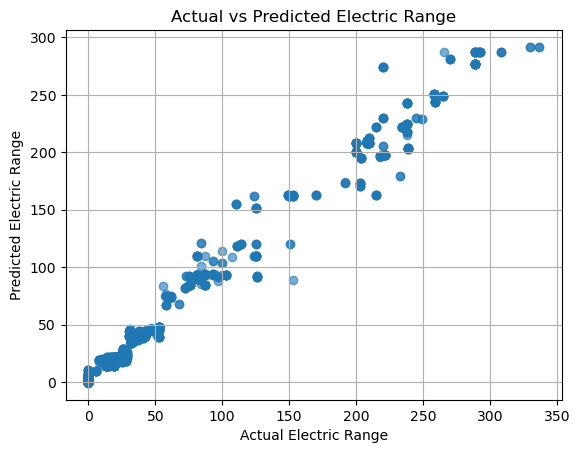

In [181]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Electric Range")
plt.ylabel("Predicted Electric Range")
plt.title("Actual vs Predicted Electric Range")
plt.grid(True)
plt.show()


In [ ]:
## Feature Importance 

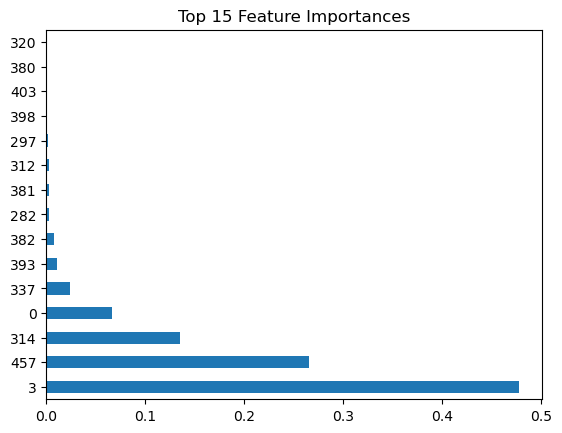

In [183]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_)
importance.nlargest(15).plot(kind='barh')
plt.title("Top 15 Feature Importances")
plt.show()
